<a href="https://colab.research.google.com/github/PusunuruVenkat/ML_PRACTICAL/blob/main/exp9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q xgboost

import time
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

from xgboost import XGBClassifier

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import drive

drive.mount('/content/drive')

print("Google Drive mounted successfully!")

Mounted at /content/drive
Google Drive mounted successfully!


In [3]:
DATA_PATH = "/content/drive/MyDrive/colab/placement_predict_50k_adjusted.csv"

TARGET_COL = "PlacementStatus"
RANDOM_STATE = 42

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset Shape: (50000, 21)


,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,CGPA,AttendancePercent,Internships,...,Workshops,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,PlacementStatus,IsAnomaly
0,Female,Delhi,Tier3,IT,DataScience,Yes,Yes,6.63,68.3,2,...,0.0,1,0,62.3,6.57,40.6,65.7,No,0,0
1,Male,Chennai,Tier2,ECE,AI,Yes,No,6.40,71.0,1,...,0.0,2,0,44.0,5.86,40.3,51.8,No,0,0
2,Female,Hyderabad,Tier3,ECE,Networking,No,No,7.73,75.1,1,...,2.0,2,1,73.8,7.50,73.6,67.9,No,1,0
3,Female,Jaipur,Tier3,ECE,Embedded,No,No,9.73,99.2,4,...,5.0,6,2,100.0,9.41,98.7,NaN,No,1,0
4,Male,Ahmedabad,Tier3,Mechanical,DataScience,No,No,9.01,99.6,2,...,NaN,4,2,90.8,9.24,83.1,100.0,No,1,0


In [4]:
print("Dataset Information:")
df.info()

print("\nDataset Columns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Gender              50000 non-null  object 
 1   City                50000 non-null  object 
 2   CollegeTier         50000 non-null  object 
 3   Stream              50000 non-null  object 
 4   Specialisation      50000 non-null  object 
 5   Hostel              50000 non-null  object 
 6   HistoryOfBacklogs   50000 non-null  object 
 7   CGPA                50000 non-null  float64
 8   AttendancePercent   50000 non-null  float64
 9   Internships         50000 non-null  int64  
 10  Projects            50000 non-null  int64  
 11  Workshops           45512 non-null  float64
 12  Certifications      50000 non-null  int64  
 13  Publications        50000 non-null  int64  
 14  AptitudeTestScore   45971 non-null  float64
 15  SoftSkillsRating    46474 non-nu

In [5]:
if "IsAnomaly" in df.columns:
    df = df.drop(columns=["IsAnomaly"])

print("IsAnomaly column removed.")

print("New Dataset Shape:", df.shape)
print("\nRemaining Columns:")
print(df.columns.tolist())

IsAnomaly column removed.
New Dataset Shape: (50000, 20)

Remaining Columns:
['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'PlacementStatus']


In [6]:
y = df[TARGET_COL].astype(int)

X = df.drop(columns=[TARGET_COL])

print("Target Column:", TARGET_COL)
print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("\nTarget Distribution:")
print(y.value_counts())


Target Column: PlacementStatus
X Shape: (50000, 19)
y Shape: (50000,)

Target Distribution:
PlacementStatus
0    26251
1    23749
Name: count, dtype: int64


In [7]:
cat_cols = X.select_dtypes(exclude="number").columns.tolist()
num_cols = X.select_dtypes(include="number").columns.tolist()

print("Categorical Columns:")
print(cat_cols)

print("\nNumerical Columns:")
print(num_cols)

print("\nNumber of Categorical Columns:", len(cat_cols))
print("Number of Numerical Columns:", len(num_cols))

Categorical Columns:
['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'ExtraCurricular']

Numerical Columns:
['CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore']

Number of Categorical Columns: 8
Number of Numerical Columns: 11


In [8]:
encoders = {}

for c in cat_cols:
    le = LabelEncoder()
    X[c] = le.fit_transform(X[c].astype(str))
    encoders[c] = le

print("Categorical features encoded successfully!")

display(X.head())


Categorical features encoded successfully!


,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,CGPA,AttendancePercent,Internships,Projects,Workshops,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular
0,0,3,2,4,1,1,1,6.63,68.3,2,2,0.0,1,0,62.3,6.57,40.6,65.7,0
1,1,2,1,2,0,1,0,6.40,71.0,1,1,0.0,2,0,44.0,5.86,40.3,51.8,0
2,0,4,2,2,3,0,0,7.73,75.1,1,2,2.0,2,1,73.8,7.50,73.6,67.9,0
3,0,5,2,2,2,0,0,9.73,99.2,4,5,5.0,6,2,100.0,9.41,98.7,NaN,0
4,1,0,2,5,1,0,0,9.01,99.6,2,3,NaN,4,2,90.8,9.24,83.1,100.0,0


In [9]:
imputer = SimpleImputer(strategy="median")

X[num_cols] = imputer.fit_transform(X[num_cols])

print("Missing numerical values handled using median imputation.")

print("Total Missing Values:", X.isnull().sum().sum())

Missing numerical values handled using median imputation.
Total Missing Values: 0


In [10]:
scaler = StandardScaler()

X[num_cols] = scaler.fit_transform(X[num_cols])

print("Numerical features scaled successfully!")

display(X.head())

Numerical features scaled successfully!


,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,CGPA,AttendancePercent,Internships,Projects,Workshops,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular
0,0,3,2,4,1,1,1,-0.668062,-0.594444,0.738470,-0.357105,-1.562754,-0.825879,-0.822550,-0.167828,0.053538,-1.047351,0.054362,0
1,1,2,1,2,0,1,0,-0.897517,-0.350585,-0.260083,-1.026919,-1.562754,-0.168709,-0.822550,-1.367295,-0.408332,-1.063646,-0.863084,0
2,0,4,2,2,3,0,0,0.429328,0.019720,-0.260083,-0.357105,-0.037000,-0.168709,0.791306,0.585936,0.658522,0.745099,0.199569,0
3,0,5,2,2,2,0,0,2.424584,2.196392,2.735575,1.652339,2.251632,2.459973,2.405162,2.303205,1.901017,2.108447,0.001559,0
4,1,0,2,5,1,0,0,1.706292,2.232520,0.738470,0.312710,-0.037000,1.145632,2.405162,1.700195,1.790428,1.261107,2.318273,0


In [11]:
VAL_SIZE = 0.15
TEST_SIZE = 0.15

# First split test data
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

# Calculate validation ratio from remaining data
val_ratio = VAL_SIZE / (1 - TEST_SIZE)

# Split training + validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=val_ratio,
    stratify=y_train_val,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (34999, 19)
Validation: (7501, 19)
Test: (7500, 19)


In [12]:
ada_base = DecisionTreeClassifier(
    max_depth=2,
    random_state=RANDOM_STATE
)

print("AdaBoost base Decision Tree created!")
print(ada_base)

AdaBoost base Decision Tree created!
DecisionTreeClassifier(max_depth=2, random_state=42)


In [13]:
ada = AdaBoostClassifier(
    estimator=ada_base,
    n_estimators=200,
    learning_rate=0.5,
    random_state=RANDOM_STATE
)

print("AdaBoost model created!")
print(ada)

AdaBoost model created!
AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2,
                                                    random_state=42),
                   learning_rate=0.5, n_estimators=200, random_state=42)


In [14]:
t0 = time.time()

ada.fit(X_train, y_train)

ada_fit_time = time.time() - t0

print("AdaBoost training completed!")
print("Training Time:", round(ada_fit_time, 2), "seconds")

AdaBoost training completed!
Training Time: 13.24 seconds


In [15]:
ada_val_pred = ada.predict(X_val)

ada_val_proba = ada.predict_proba(X_val)[:, 1]

print("AdaBoost predictions completed!")

print("\nFirst 10 Predictions:")
print(ada_val_pred[:10])

print("\nFirst 10 Probabilities:")
print(ada_val_proba[:10])

AdaBoost predictions completed!

First 10 Predictions:
[1 0 0 0 0 1 0 0 0 0]

First 10 Probabilities:
[0.5590864  0.43856637 0.15774636 0.36208478 0.43099988 0.67019045
 0.38176414 0.45459515 0.31017942 0.21925008]


In [16]:
ada_accuracy = accuracy_score(y_val, ada_val_pred)

ada_f1 = f1_score(y_val, ada_val_pred)

ada_roc_auc = roc_auc_score(y_val, ada_val_proba)

print("\n============================================")
print("ADABOOST RESULTS")
print("============================================")

print("Validation Accuracy:", round(ada_accuracy, 4))
print("Validation F1 Score:", round(ada_f1, 4))
print("Validation ROC-AUC:", round(ada_roc_auc, 4))
print("Number of Trees:", ada.n_estimators)
print("Training Time:", round(ada_fit_time, 2), "seconds")

print("============================================")


ADABOOST RESULTS
Validation Accuracy: 0.7963
Validation F1 Score: 0.781
Validation ROC-AUC: 0.8802
Number of Trees: 200
Training Time: 13.24 seconds


In [17]:
xgb = XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    early_stopping_rounds=30,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("XGBoost model created!")
print(xgb)

XGBoost model created!
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=30,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=-1,
              num_parallel_tree=None, ...)


In [18]:
t0 = time.time()

xgb.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_fit_time = time.time() - t0

print("XGBoost training completed!")
print("Training Time:", round(xgb_fit_time, 2), "seconds")

XGBoost training completed!
Training Time: 5.47 seconds


In [19]:
xgb_val_pred = xgb.predict(X_val)

xgb_val_proba = xgb.predict_proba(X_val)[:, 1]

print("XGBoost predictions completed!")

print("\nFirst 10 Predictions:")
print(xgb_val_pred[:10])

print("\nFirst 10 Probabilities:")
print(xgb_val_proba[:10])

XGBoost predictions completed!

First 10 Predictions:
[1 0 0 0 0 1 0 0 0 0]

First 10 Probabilities:
[0.6262412  0.282017   0.01268694 0.2755825  0.28624576 0.8810134
 0.2391365  0.39919353 0.08599969 0.03049057]


In [20]:
xgb_accuracy = accuracy_score(y_val, xgb_val_pred)

xgb_f1 = f1_score(y_val, xgb_val_pred)

xgb_roc_auc = roc_auc_score(y_val, xgb_val_proba)

print("\n============================================")
print("XGBOOST RESULTS")
print("============================================")

print("Validation Accuracy:", round(xgb_accuracy, 4))
print("Validation F1 Score:", round(xgb_f1, 4))
print("Validation ROC-AUC:", round(xgb_roc_auc, 4))
print("Trees Used:", xgb.best_iteration + 1)
print("Training Time:", round(xgb_fit_time, 2), "seconds")

print("============================================")


XGBOOST RESULTS
Validation Accuracy: 0.7959
Validation F1 Score: 0.7827
Validation ROC-AUC: 0.8826
Trees Used: 135
Training Time: 5.47 seconds


In [21]:
results = [
    {
        "Model": "AdaBoost",
        "Validation Accuracy": ada_accuracy,
        "Validation F1": ada_f1,
        "Validation ROC-AUC": ada_roc_auc,
        "Trees Used": ada.n_estimators,
        "Training Time (sec)": round(ada_fit_time, 2)
    },
    {
        "Model": "XGBoost",
        "Validation Accuracy": xgb_accuracy,
        "Validation F1": xgb_f1,
        "Validation ROC-AUC": xgb_roc_auc,
        "Trees Used": xgb.best_iteration + 1,
        "Training Time (sec)": round(xgb_fit_time, 2)
    }
]

results_df = pd.DataFrame(results)

display(results_df)

,Model,Validation Accuracy,Validation F1,Validation ROC-AUC,Trees Used,Training Time (sec)
0,AdaBoost,0.796294,0.780963,0.880162,200,13.24
1,XGBoost,0.795894,0.782744,0.882638,135,5.47


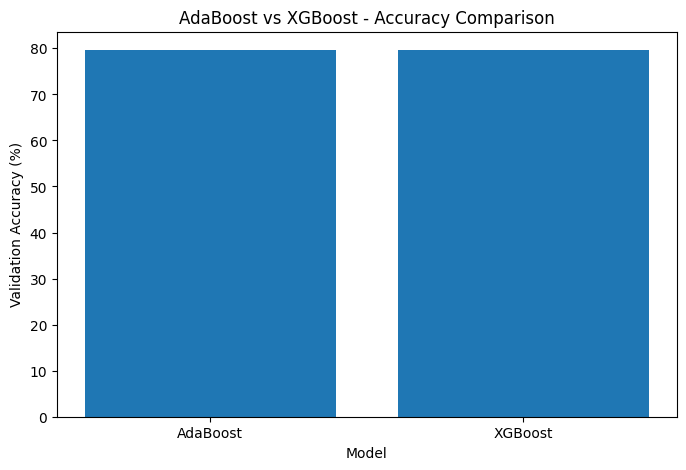

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Model"],
    results_df["Validation Accuracy"] * 100
)

plt.xlabel("Model")
plt.ylabel("Validation Accuracy (%)")
plt.title("AdaBoost vs XGBoost - Accuracy Comparison")

plt.show()

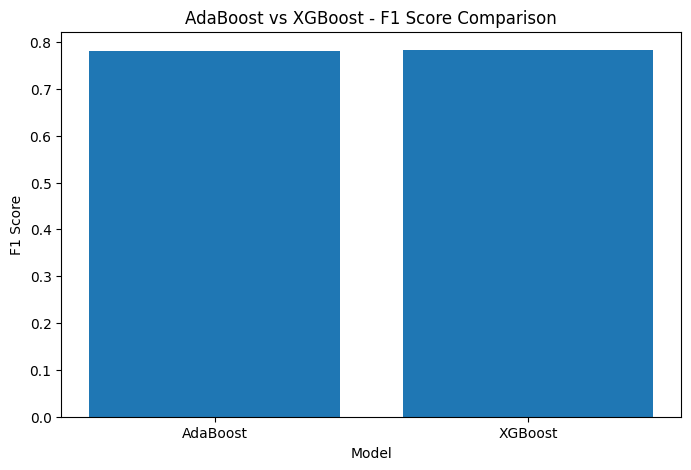

In [23]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Model"],
    results_df["Validation F1"]
)

plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.title("AdaBoost vs XGBoost - F1 Score Comparison")

plt.show()

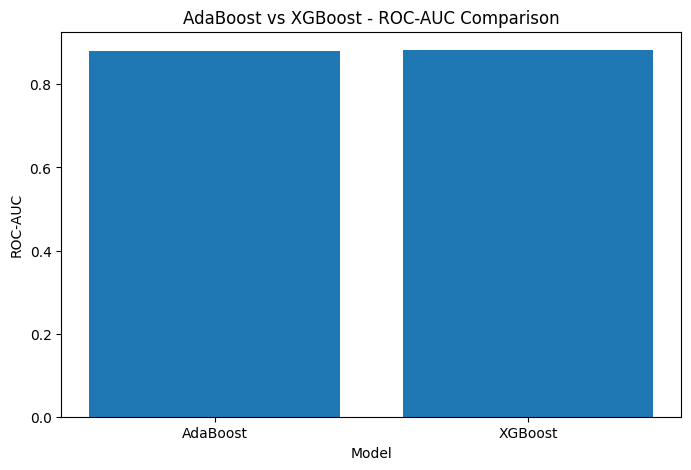

In [24]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Model"],
    results_df["Validation ROC-AUC"]
)

plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.title("AdaBoost vs XGBoost - ROC-AUC Comparison")

plt.show()

In [25]:
OUTPUT_PATH = "/content/drive/MyDrive/colab/boosting_benchmark_results.csv"

results_df.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Results saved successfully!")
print("File:", OUTPUT_PATH)

Results saved successfully!
File: /content/drive/MyDrive/colab/boosting_benchmark_results.csv


In [26]:
print("\n")
print("=" * 60)
print("        EXPERIMENT 9 - FINAL RESULTS")
print("=" * 60)

print("\nAdaBoost")
print("-" * 30)
print("Accuracy      :", round(ada_accuracy, 4))
print("F1 Score      :", round(ada_f1, 4))
print("ROC-AUC       :", round(ada_roc_auc, 4))
print("Trees Used    :", ada.n_estimators)
print("Training Time :", round(ada_fit_time, 2), "sec")

print("\nXGBoost")
print("-" * 30)
print("Accuracy      :", round(xgb_accuracy, 4))
print("F1 Score      :", round(xgb_f1, 4))
print("ROC-AUC       :", round(xgb_roc_auc, 4))
print("Trees Used    :", xgb.best_iteration + 1)
print("Training Time :", round(xgb_fit_time, 2), "sec")

print("\n" + "=" * 60)
print("Experiment 9 Completed Successfully!")
print("=" * 60)



        EXPERIMENT 9 - FINAL RESULTS

AdaBoost
------------------------------
Accuracy      : 0.7963
F1 Score      : 0.781
ROC-AUC       : 0.8802
Trees Used    : 200
Training Time : 13.24 sec

XGBoost
------------------------------
Accuracy      : 0.7959
F1 Score      : 0.7827
ROC-AUC       : 0.8826
Trees Used    : 135
Training Time : 5.47 sec

Experiment 9 Completed Successfully!
